# Cross-correlación espacial entre dos variables

En los capítulos anteriores se estudiaron medidas de autocorrelación espacial para una sola variable, como el $I$ de Moran global, el $I$ de Moran local, la $C$ de Geary y otras estadísticas LISA. En esta sección se introduce una extensión útil cuando el interés no es estudiar la dependencia espacial de una sola variable, sino la relación espacial entre dos variables.

La pregunta central es la siguiente:

> ¿Los valores de una variable en una unidad espacial están asociados con los valores de otra variable en las unidades vecinas?

Para ilustrarlo, usaremos dos variables cantonales de Ecuador:

- `VAB_PC`: Valor agregado bruto no petrolero per cápita.
- `POBRES_P`: porcentaje de población con Necesidades Básicas Insatisfechas.

El objetivo es construir una versión en Python de la idea presentada en la sección de *cross-correlación espacial* del material en R.

## Librerías

Usaremos `geopandas` para datos espaciales, `libpysal` para la matriz de pesos espaciales y `numpy/scipy` para implementar los estadísticos de cross-correlación espacial.

Si alguna librería no está instalada, puede instalarse con:

```bash
pip install geopandas libpysal esda mapclassify matplotlib scipy requests
```

In [16]:
import os
import zipfile
import tempfile
from io import BytesIO

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy import stats
from libpysal.weights import Queen
from libpysal.weights.spatial_lag import lag_spatial

## Lectura de datos

La función `read_git_shp()` permite leer un shapefile comprimido alojado en GitHub. Esta estructura mantiene el mismo estilo de los capítulos previos del material.

In [17]:
def read_git_shp(nombre, url):
    """
    Lee un shapefile específico desde un archivo .zip disponible en una URL.

    Parámetros
    ----------
    nombre : str
        Nombre del shapefile sin extensión .shp.
    url : str
        URL directa al archivo .zip.

    Retorna
    -------
    geopandas.GeoDataFrame
    """
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Error al descargar shapefile: {response.status_code}")

    zip_bytes = BytesIO(response.content)

    with zipfile.ZipFile(zip_bytes, "r") as z:
        shp_files = [f for f in z.namelist() if f.endswith(nombre + ".shp")]
        if not shp_files:
            raise FileNotFoundError(f"No se encontró {nombre}.shp en el archivo zip")

        shp_name = shp_files[0]

        with tempfile.TemporaryDirectory() as tmpdirname:
            z.extractall(tmpdirname)
            gdf = gpd.read_file(os.path.join(tmpdirname, shp_name))

    return gdf

Ahora cargamos los datos económicos, de población y de pobreza por NBI. Luego calculamos el VAB per cápita y unimos esa información con los polígonos cantonales.

In [18]:
# Valor agregado bruto no petrolero por cantón
url_vab = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/VABNoPetroleroCantones2007-2019.csv"
datos = pd.read_csv(url_vab, sep=",")

datos["COD_CANT"] = datos["COD_CANT"].astype(str)
datos.loc[datos["COD_CANT"].str.len() == 3, "COD_CANT"] = "0" + datos.loc[datos["COD_CANT"].str.len() == 3, "COD_CANT"]
datos = datos[datos["YEAR"] == 2019].copy()

# Población cantonal proyectada
url_poblacion = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/proyeccion_cantonal_total_2010-2020.csv"
poblacion = pd.read_csv(url_poblacion, sep=";")
poblacion["CODIGO"] = poblacion["CODIGO"].astype(str)
poblacion.loc[poblacion["CODIGO"].str.len() == 3, "CODIGO"] = "0" + poblacion.loc[poblacion["CODIGO"].str.len() == 3, "CODIGO"]

# Necesidades Básicas Insatisfechas por cantón
url_nbi = "https://raw.githubusercontent.com/vmoprojs/DataLectures/master/SpatialData/NBI_PER_CANT.csv"
nbi = pd.read_csv(url_nbi, sep=";")
nbi["CODIGO"] = nbi["CODIGO"].astype(str)
nbi.loc[nbi["CODIGO"].str.len() == 3, "CODIGO"] = "0" + nbi.loc[nbi["CODIGO"].str.len() == 3, "CODIGO"]

# Unión de bases
datos = datos.merge(
    poblacion[["CODIGO", "A_2019"]],
    left_on="COD_CANT",
    right_on="CODIGO",
    how="left"
)

datos = datos.merge(
    nbi[["CODIGO", "POBRES_P"]],
    left_on="COD_CANT",
    right_on="CODIGO",
    how="left"
)

# VAB per cápita: miles de USD por persona
datos["VAB_PC"] = datos["VAB"] / datos["A_2019"]

# Polígonos cantonales
url_shp = "https://github.com/vmoprojs/DataLectures/raw/master/SpatialData/SHP.zip"
poligonos = read_git_shp("nxcantones", url_shp)

# Se excluyen Galápagos y zonas no continentales según el tratamiento usado en capítulos previos
poligonos = poligonos[poligonos["DPA_PROVIN"] != "90"].copy()
poligonos = poligonos[poligonos["DPA_PROVIN"] != "20"].copy()

# Unión espacial-tabular
poligonos = poligonos.merge(
    datos,
    left_on="DPA_CANTON",
    right_on="COD_CANT",
    how="left"
)

# Se conservan observaciones completas para las dos variables de interés
poligonos = poligonos.dropna(subset=["VAB_PC", "POBRES_P"]).copy()
poligonos = poligonos.reset_index(drop=True)

poligonos[["DPA_CANTON", "DPA_DESCAN", "VAB_PC", "POBRES_P"]].head()

,DPA_CANTON,DPA_DESCAN,VAB_PC,POBRES_P
0,0201,GUARANDA,3.602965,0.779
1,0202,CHILLANES,1.473314,0.850
2,0203,CHIMBO,1.705014,0.739
3,0204,ECHEANDIA,2.214648,0.671
4,0205,SAN MIGUEL,1.524756,0.748


## Visualización inicial de las variables

Antes de calcular la cross-correlación espacial, revisamos la distribución espacial de las dos variables.

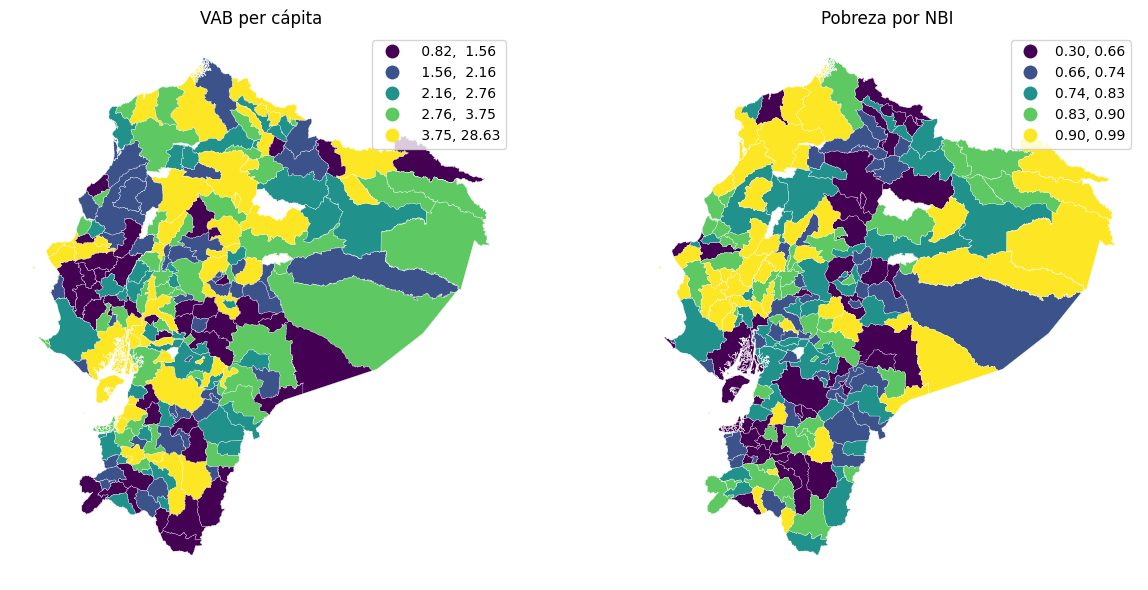

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6))

poligonos.plot(
    column="VAB_PC",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axs[0]
)
axs[0].set_title("VAB per cápita")
axs[0].axis("off")

poligonos.plot(
    column="POBRES_P",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axs[1]
)
axs[1].set_title("Pobreza por NBI")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Matriz de pesos espaciales por contigüidad

El primer ejercicio usa una matriz de contigüidad tipo reina. Esta matriz identifica como vecinos a los cantones que comparten borde o vértice.

Luego se estandariza por filas, de manera que el rezago espacial de una variable pueda interpretarse como el promedio ponderado de los valores de sus vecinos.

In [20]:
w_queen = Queen.from_dataframe(poligonos, silence_warnings=True, use_index=True)
w_queen.transform = "R"

print(f"Número de cantones: {w_queen.n}")
print(f"Número de islas: {len(w_queen.islands)}")
print(f"Islas: {w_queen.islands}")

Número de cantones: 215
Número de islas: 13
Islas: [27, 59, 91, 97, 99, 103, 113, 114, 118, 130, 184, 185, 211]


## Cross-correlación espacial global

La cross-correlación espacial global permite medir si una variable observada en una unidad espacial se relaciona con otra variable observada en las unidades vecinas.

Una forma general de expresar el índice global es:

$$
R_c = x^T W y
$$

Donde:

- $x$ es la primera variable estandarizada.
- $y$ es la segunda variable estandarizada.
- $W$ es la matriz de pesos espaciales.

En este notebook usaremos una versión normalizada de $x$ e $y$ para que el estadístico sea comparable entre ejercicios. Esta implementación es didáctica y reproduce la lógica conceptual del GSCI, aunque puede no coincidir exactamente con la implementación interna de `spatialEco::crossCorrelation()` en R.

In [21]:
def standardize_vector(x):
    """Estandariza un vector con media 0 y desviación estándar 1."""
    x = np.asarray(x, dtype=float)
    return (x - np.nanmean(x)) / np.nanstd(x, ddof=1)


def unit_norm(x):
    """Escala un vector para que su norma euclídea sea igual a 1."""
    x = np.asarray(x, dtype=float)
    norm = np.sqrt(np.sum(x ** 2))
    if norm == 0:
        raise ValueError("El vector tiene norma cero y no puede normalizarse.")
    return x / norm


def w_to_matrix(w):
    """Convierte un objeto libpysal.weights.W en matriz densa."""
    matrix, ids = w.full()
    return np.asarray(matrix, dtype=float), ids


def global_spatial_cross_correlation(x, y, w, standardize=True, normalize=True):
    """
    Calcula una versión didáctica del índice global de cross-correlación espacial.

    Rc = x' W y
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    W, _ = w_to_matrix(w)

    if standardize:
        x = standardize_vector(x)
        y = standardize_vector(y)

    if normalize:
        x = unit_norm(x)
        y = unit_norm(y)

    rc = float(x.T @ W @ y)
    return rc


def permutation_test_global_cross_correlation(x, y, w, permutations=999, seed=12345):
    """
    Prueba de permutación para el índice global de cross-correlación espacial.

    La hipótesis nula es ausencia de asociación espacial cruzada entre x y y.
    Se permuta y manteniendo fija la estructura espacial W.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    observed = global_spatial_cross_correlation(x, y, w)
    simulated = np.empty(permutations)

    for p in range(permutations):
        y_perm = rng.permutation(y)
        simulated[p] = global_spatial_cross_correlation(x, y_perm, w)

    p_value = (np.sum(np.abs(simulated) >= np.abs(observed)) + 1) / (permutations + 1)

    return {
        "Rc": observed,
        "p_value": p_value,
        "simulated": simulated,
        "permutations": permutations
    }

In [22]:
x = poligonos["VAB_PC"].to_numpy()
y = poligonos["POBRES_P"].to_numpy()

resultado_global = permutation_test_global_cross_correlation(
    x=x,
    y=y,
    w=w_queen,
    permutations=999,
    seed=12345
)

resultado_global["Rc"], resultado_global["p_value"]

(-0.09943002318341664, np.float64(0.005))

El valor de `Rc` resume la asociación entre `VAB_PC` en cada cantón y el rezago espacial de `POBRES_P` en sus vecinos.

La interpretación general es:

- `Rc > 0`: cantones con valores altos de `VAB_PC` tienden a estar rodeados por cantones con valores altos de `POBRES_P`, o cantones con valores bajos de `VAB_PC` tienden a estar rodeados por cantones con valores bajos de `POBRES_P`.
- `Rc < 0`: cantones con valores altos de `VAB_PC` tienden a estar rodeados por cantones con valores bajos de `POBRES_P`, o viceversa.
- `Rc` cercano a cero: no se observa una asociación espacial cruzada global clara.

El `p_value` se obtiene por permutación. Si es pequeño, se rechaza la hipótesis de ausencia de asociación espacial cruzada.

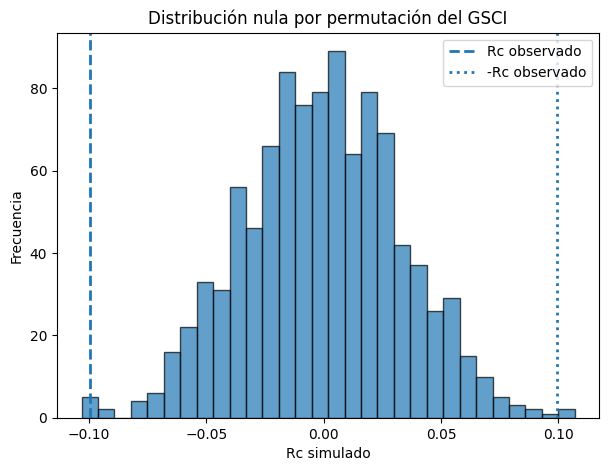

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(resultado_global["simulated"], bins=30, edgecolor="black", alpha=0.7)
ax.axvline(resultado_global["Rc"], linestyle="--", linewidth=2, label="Rc observado")
ax.axvline(-resultado_global["Rc"], linestyle=":", linewidth=2, label="-Rc observado")
ax.set_title("Distribución nula por permutación del GSCI")
ax.set_xlabel("Rc simulado")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.show()

## Relación con la correlación de Pearson

La correlación tradicional de Pearson mide la asociación directa entre dos variables observadas en las mismas unidades espaciales. En cambio, la cross-correlación espacial mide la relación entre una variable y el entorno espacial de otra variable.

En términos conceptuales, puede pensarse en la siguiente descomposición:

$$
R_0 = R_c + R_p
$$

Donde:

- $R_0$ es la correlación de Pearson entre $x$ e $y$.
- $R_c$ es la cross-correlación espacial global.
- $R_p$ es la parte de la correlación no atribuida al componente espacial cruzado.

Esta descomposición debe interpretarse con cuidado porque depende de la forma de escalar las variables y la matriz de pesos.

In [24]:
R0 = stats.pearsonr(x, y).statistic
Rc = resultado_global["Rc"]
Rp = R0 - Rc

pd.DataFrame({
    "Indicador": ["R0: Pearson", "Rc: cross-correlación espacial", "Rp: componente parcial aproximado"],
    "Valor": [R0, Rc, Rp]
})

,Indicador,Valor
0,R0: Pearson,-0.354716
1,Rc: cross-correlación espacial,-0.099430
2,Rp: componente parcial aproximado,-0.255286


## Cross-correlación espacial local

La versión local permite identificar qué cantones contribuyen más al patrón espacial cruzado. Una forma de expresar el índice local es:

$$
R_i^{(xy)} = x_i \sum_j w_{ij} y_j
$$

Es decir, se compara el valor de $x$ en el cantón $i$ con el promedio espacial de $y$ en sus vecinos.

En esta aplicación:

$$
R_i^{(xy)} = VAB\_PC_i \times W(POBRES\_P)_i
$$

Por tanto, el indicador local ayuda a identificar cantones donde el nivel de actividad económica per cápita está asociado con la pobreza observada en el entorno vecino.

In [25]:
def local_spatial_cross_correlation(x, y, w, standardize=True, scale_to_unit=True):
    """
    Calcula una versión local del índice de cross-correlación espacial.

    LSCI_xy = x_i * sum_j w_ij y_j
    LSCI_yx = y_i * sum_j w_ij x_j
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if standardize:
        x_s = standardize_vector(x)
        y_s = standardize_vector(y)
    else:
        x_s = x.copy()
        y_s = y.copy()

    lag_y = lag_spatial(w, y_s)
    lag_x = lag_spatial(w, x_s)

    lsci_xy = x_s * lag_y
    lsci_yx = y_s * lag_x

    if scale_to_unit:
        max_xy = np.nanmax(np.abs(lsci_xy))
        max_yx = np.nanmax(np.abs(lsci_yx))
        if max_xy > 0:
            lsci_xy = lsci_xy / max_xy
        if max_yx > 0:
            lsci_yx = lsci_yx / max_yx

    return pd.DataFrame({
        "lsci_xy": lsci_xy,
        "lsci_yx": lsci_yx,
        "x_std": x_s,
        "y_std": y_s,
        "lag_y_std": lag_y,
        "lag_x_std": lag_x
    })

lsci = local_spatial_cross_correlation(x, y, w_queen)
lsci.head()

,lsci_xy,lsci_yx,x_std,y_std,lag_y_std,lag_x_std
0,-0.008582,-0.003401,0.206687,0.097646,-0.211456,-0.142584
1,-0.045760,-0.044380,-0.591908,0.616644,0.393694,-0.294629
2,0.006627,-0.005578,-0.505023,-0.194748,-0.066826,0.117262
3,0.008175,0.028071,-0.313916,-0.691817,-0.132614,-0.166110
4,-0.028241,0.003900,-0.572617,-0.128959,0.251152,-0.123812


In [26]:
poligonos = poligonos.join(lsci)

poligonos[["DPA_DESCAN", "VAB_PC", "POBRES_P", "lsci_xy", "lsci_yx"]].head()

,DPA_DESCAN,VAB_PC,POBRES_P,lsci_xy,lsci_yx
0,GUARANDA,3.602965,0.779,-0.008582,-0.003401
1,CHILLANES,1.473314,0.850,-0.045760,-0.044380
2,CHIMBO,1.705014,0.739,0.006627,-0.005578
3,ECHEANDIA,2.214648,0.671,0.008175,0.028071
4,SAN MIGUEL,1.524756,0.748,-0.028241,0.003900


## Tipología local de asociación cruzada

Para interpretar el indicador local puede construirse una clasificación similar al gráfico de Moran, pero usando una variable y el rezago espacial de la otra.

La clasificación para `lsci_xy` se basa en:

- `x_std`: valor estandarizado de `VAB_PC`.
- `lag_y_std`: rezago espacial estandarizado de `POBRES_P`.

Así se obtienen cuatro combinaciones:

- `Alto-Alto`: VAB per cápita alto rodeado de pobreza alta.
- `Alto-Bajo`: VAB per cápita alto rodeado de pobreza baja.
- `Bajo-Alto`: VAB per cápita bajo rodeado de pobreza alta.
- `Bajo-Bajo`: VAB per cápita bajo rodeado de pobreza baja.

In [27]:
def clasificar_cross_cluster(row):
    if row["x_std"] >= 0 and row["lag_y_std"] >= 0:
        return "Alto-Alto"
    elif row["x_std"] >= 0 and row["lag_y_std"] < 0:
        return "Alto-Bajo"
    elif row["x_std"] < 0 and row["lag_y_std"] >= 0:
        return "Bajo-Alto"
    else:
        return "Bajo-Bajo"

poligonos["cluster_xy"] = poligonos.apply(clasificar_cross_cluster, axis=1)
poligonos["cluster_xy"].value_counts()

cluster_xy
Bajo-Bajo    74
Bajo-Alto    70
Alto-Bajo    39
Alto-Alto    32
Name: count, dtype: int64

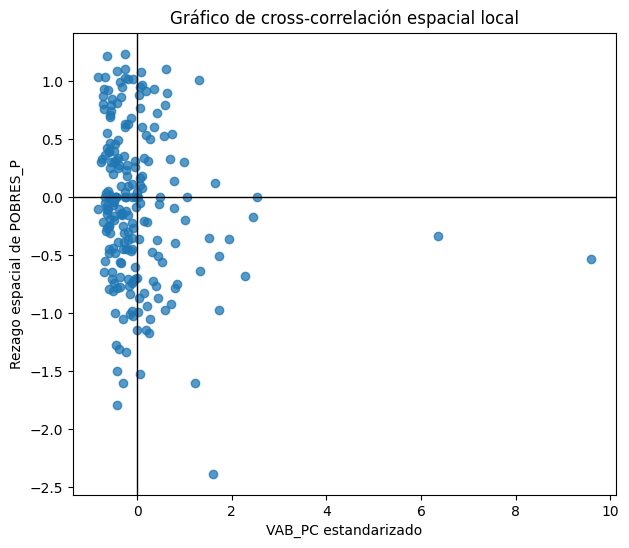

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(poligonos["x_std"], poligonos["lag_y_std"], alpha=0.75)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("VAB_PC estandarizado")
ax.set_ylabel("Rezago espacial de POBRES_P")
ax.set_title("Gráfico de cross-correlación espacial local")

plt.show()

## Mapa del indicador local

El siguiente mapa muestra el indicador `lsci_xy`. Valores positivos indican concordancia entre `VAB_PC` y el rezago espacial de `POBRES_P`; valores negativos indican asociación cruzada inversa.

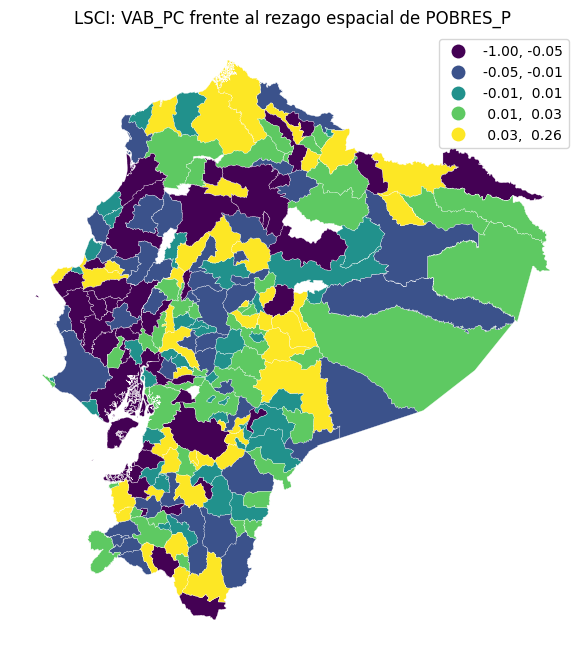

In [29]:
fig, ax = plt.subplots(figsize=(9, 8))

poligonos.plot(
    column="lsci_xy",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

ax.set_title("LSCI: VAB_PC frente al rezago espacial de POBRES_P")
ax.axis("off")
plt.show()

También puede mapearse la tipología local de asociación cruzada.

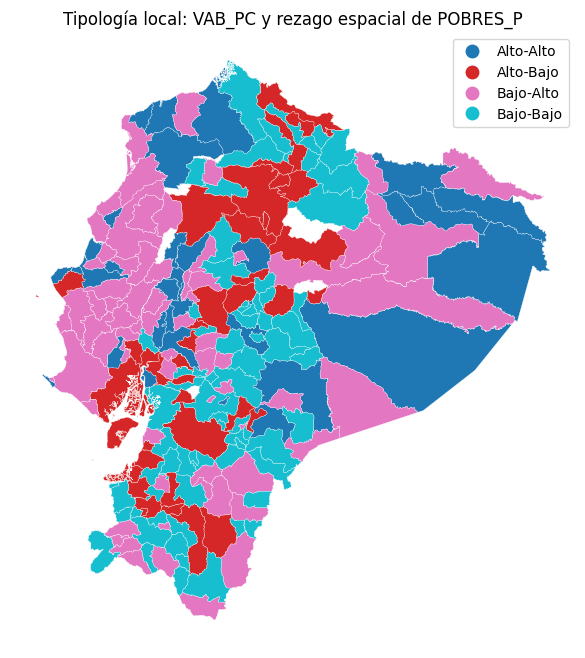

In [30]:
fig, ax = plt.subplots(figsize=(9, 8))

poligonos.plot(
    column="cluster_xy",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

ax.set_title("Tipología local: VAB_PC y rezago espacial de POBRES_P")
ax.axis("off")
plt.show()

## Versión alternativa con matriz de distancia inversa

La sección original también compara una especificación basada en distancia. En Python podemos construir una matriz de distancia entre centroides y transformarla en pesos de distancia inversa.

La lógica es:

$$
w_{ij} = \frac{1}{d_{ij}^p}
$$

para $i \neq j$, donde $p$ controla qué tan rápido cae la influencia con la distancia. Luego se estandariza por filas.

In [31]:
def inverse_distance_weights_from_centroids(gdf, power=2, threshold=None):
    """
    Construye una matriz densa de pesos de distancia inversa usando centroides.

    Parámetros
    ----------
    gdf : geopandas.GeoDataFrame
        GeoDataFrame con geometrías proyectadas.
    power : int o float
        Potencia de la distancia inversa.
    threshold : float, opcional
        Distancia máxima para considerar vecinos. Si es None, todos son vecinos.

    Retorna
    -------
    numpy.ndarray
        Matriz row-standardized de pesos espaciales.
    """
    centroids = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])
    diff = centroids[:, None, :] - centroids[None, :, :]
    dist = np.sqrt(np.sum(diff ** 2, axis=2))

    W = np.zeros_like(dist, dtype=float)
    mask = dist > 0

    if threshold is not None:
        mask = mask & (dist <= threshold)

    W[mask] = 1 / (dist[mask] ** power)

    row_sums = W.sum(axis=1)
    nonzero = row_sums > 0
    W[nonzero] = W[nonzero] / row_sums[nonzero, None]

    return W


def global_cross_correlation_matrix(x, y, W, standardize=True, normalize=True):
    """Calcula Rc usando directamente una matriz W densa."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if standardize:
        x = standardize_vector(x)
        y = standardize_vector(y)

    if normalize:
        x = unit_norm(x)
        y = unit_norm(y)

    return float(x.T @ W @ y)

# El shapefile ya está en un CRS proyectado. Si estuviera en coordenadas geográficas,
# convendría reproyectarlo antes de calcular distancias.
W_id = inverse_distance_weights_from_centroids(poligonos, power=2)
Rc_id = global_cross_correlation_matrix(x, y, W_id)

Rc_id

-0.04023911724405837

In [32]:
def local_cross_correlation_matrix(x, y, W, standardize=True, scale_to_unit=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if standardize:
        x_s = standardize_vector(x)
        y_s = standardize_vector(y)
    else:
        x_s = x.copy()
        y_s = y.copy()

    lag_y = W @ y_s
    lag_x = W @ x_s

    lsci_xy = x_s * lag_y
    lsci_yx = y_s * lag_x

    if scale_to_unit:
        max_xy = np.nanmax(np.abs(lsci_xy))
        max_yx = np.nanmax(np.abs(lsci_yx))
        if max_xy > 0:
            lsci_xy = lsci_xy / max_xy
        if max_yx > 0:
            lsci_yx = lsci_yx / max_yx

    return pd.DataFrame({
        "cross_cor_id": lsci_xy,
        "cross_cor_id_yx": lsci_yx,
        "lag_y_id": lag_y,
        "lag_x_id": lag_x
    })

lsci_id = local_cross_correlation_matrix(x, y, W_id)
poligonos = poligonos.join(lsci_id)

poligonos[["DPA_DESCAN", "lsci_xy", "cross_cor_id"]].head()

,DPA_DESCAN,lsci_xy,cross_cor_id
0,GUARANDA,-0.008582,-0.000999
1,CHILLANES,-0.045760,0.003522
2,CHIMBO,0.006627,0.016110
3,ECHEANDIA,0.008175,-0.013198
4,SAN MIGUEL,-0.028241,-0.003380


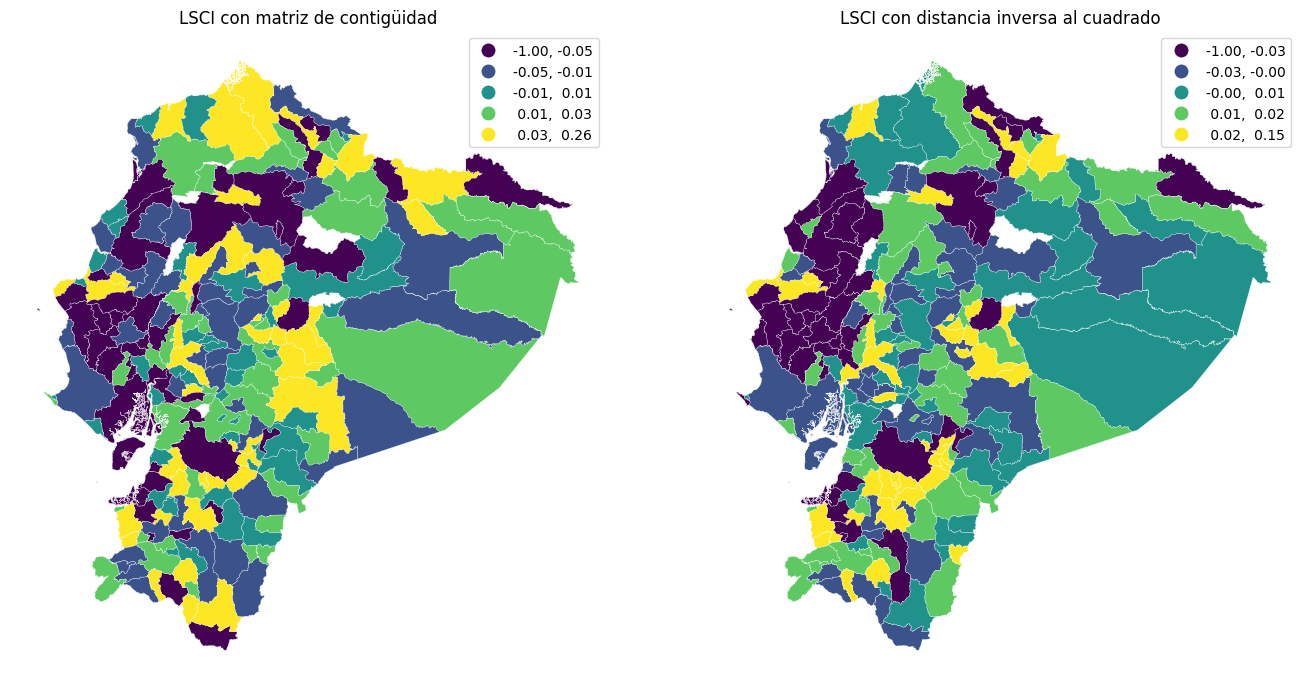

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

poligonos.plot(
    column="lsci_xy",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axs[0]
)
axs[0].set_title("LSCI con matriz de contigüidad")
axs[0].axis("off")

poligonos.plot(
    column="cross_cor_id",
    scheme="quantiles",
    k=5,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=axs[1]
)
axs[1].set_title("LSCI con distancia inversa al cuadrado")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Comparación de resultados globales

Finalmente comparamos la correlación de Pearson con las dos versiones de cross-correlación espacial global.

In [34]:
resumen = pd.DataFrame({
    "Indicador": [
        "Pearson entre VAB_PC y POBRES_P",
        "GSCI con matriz de contigüidad tipo reina",
        "GSCI con distancia inversa al cuadrado"
    ],
    "Valor": [R0, Rc, Rc_id]
})

resumen

,Indicador,Valor
0,Pearson entre VAB_PC y POBRES_P,-0.354716
1,GSCI con matriz de contigüidad tipo reina,-0.099430
2,GSCI con distancia inversa al cuadrado,-0.040239


## Interpretación 

La correlación de Pearson responde si los cantones con mayor VAB per cápita tienden a presentar mayor o menor pobreza por NBI en el mismo cantón. La cross-correlación espacial responde una pregunta distinta: si los cantones con mayor VAB per cápita tienden a estar rodeados por cantones con mayor o menor pobreza.

Por ello, ambos resultados pueden diferir. Una correlación de Pearson negativa, por ejemplo, indicaría que los cantones con mayor VAB per cápita tienden a tener menor pobreza. En cambio, un GSCI cercano a cero indicaría que esa relación directa no necesariamente se expresa como un patrón espacial cruzado entre cada cantón y sus vecinos.

La versión local permite pasar del resumen global al diagnóstico territorial. Los mapas de `lsci_xy` y `cluster_xy` ayudan a identificar cantones donde la relación entre actividad económica y pobreza del entorno es más intensa, inversa o atípica.

## Para recordar

La cross-correlación espacial es útil cuando se quiere estudiar la asociación entre dos variables incorporando explícitamente la estructura de vecindad. En términos aplicados, permite distinguir entre una relación directa entre variables y una relación mediada por el entorno espacial.

En Python, este notebook implementa una versión transparente y modificable del GSCI/LSCI. Esto tiene una ventaja pedagógica: cada paso del cálculo queda visible y puede adaptarse a otras matrices de pesos, otras variables o pruebas de permutación más específicas.